<>:74: SyntaxWarning: invalid escape sequence '\p'
<>:74: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_570315/3651973375.py:74: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$|\psi \\rangle$')


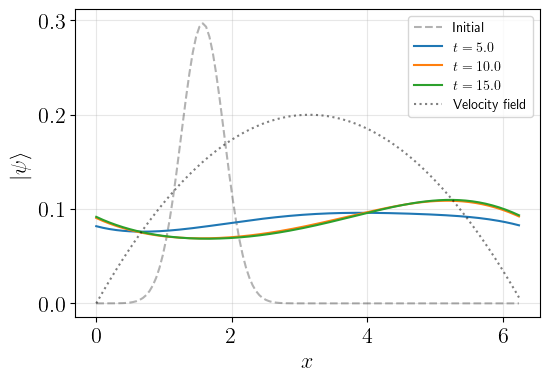

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# subroutine for QFT matrix (and its inverse) on n qubits
def get_qft_mat(n):
    num_states = 1<<n # this is 2**n
    omega = np.exp(-2j*np.pi/num_states)

    qft = np.zeros((num_states,num_states),dtype=complex)

    for i in range(num_states):
        for j in range(num_states):
            qft[i][j] = omega**(i*j)/np.sqrt(num_states)

    qft_inv = qft.transpose().conjugate()

    return qft, qft_inv

# parameters
n = 7 # number of qubits
N = 2**n # number of grid points
L = 2*np.pi # length of the box
dx = L/N # grid spacing
x = np.arange(N)*dx # grid points
times = np.arange(5, 16, 5)
D = 1.0 # diffusion coeff

#c = 0.1*np.sin(2*np.pi*x/L) + 0.2 # velocity field
#cx = 0.1*2*np.pi/L * np.cos(2*np.pi*x/L) # velocity field gradient
c_L = 0.0
c_H = 0.2
c = -4*(c_H -c_L)/L**2 *x**2 + 4*(c_H -c_L)/L *x # velocity field
cx = -8*(c_H - c_L)/L**2 *x + 4*(c_H -c_L)/L  # velocity field gradient

# initial condition
sigma = L/20
state_i = np.exp(-0.5*((x-dx*N/4)/sigma)**2)
state_i = state_i / np.linalg.norm(state_i) # normalize the initial state

j_indices = np.arange(N)
k_j = 2*np.pi /L * np.where(j_indices < N/2, j_indices, j_indices - N)
P1 = np.diag(1j*k_j)
P2 = np.diag(-k_j**2)
QFT, QFT_inv = get_qft_mat(n)
D1 = QFT_inv @ P1 @ QFT
D2 = QFT_inv @ P2 @ QFT

A = - (D*D2-0.5*(np.diag(c) @ D1 + D1 @ np.diag(c)) - np.diag(cx))




plt.rcParams.update({
    "text.usetex": True,
    "font.weight": "bold",      # Bolds standard text
    "axes.labelweight": "bold", # Bolds axis labels
    "figure.figsize": (6, 4), # SMALLER figure = LARGER relative text
    "axes.labelsize": 16,       # Now 14 will look huge and readable
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})
plt.figure()
plt.plot(x, state_i, 'k--', label='Initial', alpha=0.3)
for t in times:

    U = expm(-A*t)
    final_state = U @ state_i
    final_state = final_state / np.linalg.norm(final_state) # normalize the final state
    plt.plot(x, final_state, label=f'$t={t:.1f}$')

plt.plot(x,c, 'k:', label='Velocity field', alpha=0.5)
plt.xlabel('$x$')
plt.ylabel('$|\psi \\rangle$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'./figures/lchs_diff_adv_D{D:.2f}.pdf', bbox_inches='tight')
plt.show()